# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
# Desenvolva aqui o DESAFIO 1
dados = pd.DataFrame(registros)
dados

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0
...,...,...,...,...,...,...,...,...,...,...,...
331,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T01:00:00.000Z,20930.443,20930.443,20909.312,19490.105,1419.2076,21.13,0
332,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T01:30:00.000Z,19936.190,19936.190,19915.059,18492.955,1422.1025,21.13,0
333,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T02:00:00.000Z,19153.877,19153.877,19132.746,17709.488,1423.2574,21.13,0
334,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T02:30:00.000Z,18149.570,18149.570,18128.440,16700.184,1428.2562,21.13,0


In [7]:
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [8]:
print((f'Número de linhas: {dados.shape[0]}'))
print((f'Número de colunas: {dados.shape[1]}'))

Número de linhas: 336
Número de colunas: 11


In [9]:
print(dados.columns)

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')


In [10]:
# Lista os nomes dos atributos
print("Nomes dos atributos:")
print(dados.columns.tolist())

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [11]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [12]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

Data e Hora:
- din_atualizacao
- dat_referencia
- din_referenciautc

Área de Carga:
- cod_areacarga

Valor de Carga:
- val_cargaglobal
- val_cargaglobalcons
- val_cargaglobalsmmgd
- val_cargasupervisionada
- val_carganaosupervisionada
- val_cargammgd


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [13]:
# Desenvolva aqui o DESAFIO 2
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [14]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [15]:
dados.rename(columns={
    'cod_areacarga':'codigo_area',
    'din_atualizacao': 'atualizacao_hora_data',
    'dat_referencia': 'referencia_data',
    'din_referenciautc': 'referencia_tempo',
    'val_cargaglobal': 'carga_global',
    'val_cargaglobalcons': 'carga_global_constante',
    'val_cargaglobalsmmgd': 'carga_global_smmgd',
    'val_cargasupervisionada': 'carga_supervisionada',
    'val_carganaosupervisionada': 'carga_nao_supervisionada',
    'val_cargammgd': 'carga_mmgd',
    'val_consistencia': 'consistencia'}, inplace = True)

In [16]:
dados.columns

Index(['codigo_area', 'atualizacao_hora_data', 'referencia_data',
       'referencia_tempo', 'carga_global', 'carga_global_constante',
       'carga_global_smmgd', 'carga_supervisionada',
       'carga_nao_supervisionada', 'carga_mmgd', 'consistencia'],
      dtype='object')

In [17]:
df1 = dados[['codigo_area','atualizacao_hora_data','carga_global']]
df1.head()

,codigo_area,atualizacao_hora_data,carga_global
0,SP,2026-08-14T05:58:29.574Z,15913.618
1,SP,2026-08-14T05:58:29.574Z,15251.414
2,SP,2026-08-14T05:58:29.574Z,14606.733
3,SP,2026-08-14T05:58:29.574Z,14182.290
4,SP,2026-08-14T05:58:29.574Z,13838.488


In [18]:
print(df1.isnull().sum())

codigo_area              0
atualizacao_hora_data    0
carga_global             0
dtype: int64


In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   codigo_area            336 non-null    object 
 1   atualizacao_hora_data  336 non-null    object 
 2   carga_global           336 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.0+ KB


Para começar o desafio 2, foi usado .head() para visualizar os atributos existentes, logo após foi utilizado o .rename para renomear os atributos para melhor compreensão dos resultados com .columns antes e depois para facilitar o feito. Foi criado o df1 apenas com três atributos (data e hora, código de área e valor de carga), após foi utilizado .isnull() junto com .sum() para verificar a presença de elementos vazios e a contagem de ambos, e logo depois foi utilizado .info() para visualizar os tipos de cada atributo e foi possivel observar que a carga_global é um float64, ou seja, uma variavel numerica enquanto atualizacao_hora_data é object


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [20]:
# Desenvolva aqui o DESAFIO 3
#Valores min, max e mean de todas as cargas
colunas_carga = [
    'carga_global',
    'carga_global_constante',
    'carga_global_smmgd',
    'carga_supervisionada',
    'carga_nao_supervisionada',
    'carga_mmgd'
]

dados[colunas_carga].describe().loc[['min', 'max', 'mean']]

,carga_global,carga_global_constante,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249


In [21]:
carga = dados['carga_global']

dados[colunas_carga].describe().loc[['min', 'max', 'mean']]

,carga_global,carga_global_constante,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249


In [22]:
#valores da mediana, amplitude e quantidade total de carga
medi = carga.median()
ampli = carga.max() - carga.min()
total = carga.count()

In [23]:
#Print dos valores
print(f"O valor da carga mínima é: {carga.min():.2f}kW")

print(f"O valor da carga máxima é: {carga.max():.2f}kW")

print(f"O valor da carga média é: {carga.mean():.2f}kW")

print(f"O valor da mediana dos valores é: {medi}kW")

print(f"O valor da amplitude entre o máximo e o mínimo é: {ampli:.2f}kW")

print(f"O valor total de medição de cargas é: {total}")

O valor da carga mínima é: 12139.25kW
O valor da carga máxima é: 23185.31kW
O valor da carga média é: 17870.83kW
O valor da mediana dos valores é: 18199.1285kW
O valor da amplitude entre o máximo e o mínimo é: 11046.06kW
O valor total de medição de cargas é: 336


A Carga Máxima é de 23.185,31kMW, enquanto a Média é de 17.870,83kW (diferença de 5.314,48kMW). A Mediana ($18.199,13kW) é próxima da média, porém um pouco mais elevada, o que indica uma tendência à registros maiores.

O valor máximo não representa um outlier, mas reflete o pico típico de demanda ocorrido nos horários comerciais/tardes dos dias úteis na região de São Paulo.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [24]:
# Desenvolva aqui o DESAFIO 4
#1. Calcule o limiar

carga_maxima = dados['carga_global'].max() # Variável criada no item 3
alta_demanda = carga_maxima * 0.9

In [25]:
#2 Crie um novo DataFrame com os registros acima dele.
df_alta_demanda = dados[dados['carga_global'] >= alta_demanda]
df_alta_demanda

,codigo_area,atualizacao_hora_data,referencia_data,referencia_tempo,carga_global,carga_global_constante,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd,consistencia
35,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T21:00:00.000Z,21088.959,21088.959,20955.120,19516.370,1438.7495,133.8406,0
36,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T21:30:00.000Z,22398.360,22398.360,22377.096,20933.746,1443.3496,21.2638,0
37,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T22:00:00.000Z,23185.312,23185.312,23164.182,21717.934,1446.2487,21.1300,0
38,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T22:30:00.000Z,22903.314,22903.314,22882.184,21433.580,1448.6025,21.1300,0
39,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T23:00:00.000Z,22358.701,22358.701,22337.570,20886.078,1451.4915,21.1300,0
40,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T23:30:00.000Z,21697.979,21697.979,21676.848,20223.252,1453.5953,21.1300,0
41,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-02T00:00:00.000Z,21385.326,21385.326,21364.195,19911.168,1453.0271,21.1300,0
42,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-02T00:30:00.000Z,20919.314,20919.314,20898.184,19445.617,1452.5674,21.1300,0
84,SP,2026-08-14T05:58:37.837Z,2025-08-02,2025-08-02T21:30:00.000Z,20983.484,20983.484,20962.176,19485.060,1477.1143,21.3080,0
85,SP,2026-08-14T05:58:37.837Z,2025-08-02,2025-08-02T22:00:00.000Z,21202.566,21202.566,21181.436,19701.352,1480.0841,21.1300,0


In [26]:
#3 Conte os registros.
print(f"Número de registros: {df_alta_demanda.shape[0]}")

Número de registros: 50


In [27]:
#4 Calcule o percentual em relação ao total.
print(f"Isso representa {df_alta_demanda.shape[0] / dados.shape[0] * 100:.2f}% dos registros")

Isso representa 14.88% dos registros


In [28]:
#5 Identifique o maior valor de carga.
print(f"O maior valor de carga é {dados['carga_global'].max()} kW")

O maior valor de carga é 23185.312 kW


In [29]:
#6 Identifique a data e o horário do pico, quando disponíveis.
df_data_pico = df_alta_demanda['referencia_tempo']
df_data_pico

,referencia_tempo
35,2025-08-01T21:00:00.000Z
36,2025-08-01T21:30:00.000Z
37,2025-08-01T22:00:00.000Z
38,2025-08-01T22:30:00.000Z
39,2025-08-01T23:00:00.000Z
40,2025-08-01T23:30:00.000Z
41,2025-08-02T00:00:00.000Z
42,2025-08-02T00:30:00.000Z
84,2025-08-02T21:30:00.000Z
85,2025-08-02T22:00:00.000Z


### Responda: Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?

De todos os registros, aproximadamente 15% constam como acima do limiar de alta demanda. Com isso, sabemos que eventos de sobrecarga da rede elétrica estão relativamente controlados.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [44]:
# Desenvolva aqui o DESAFIO 5

carga_media = dados['carga_global'].mean()

df5 = dados[dados['carga_global'] > carga_media]

df5_qnt_registros = df5.shape[0]

df5_percentual = df5_qnt_registros / dados.shape[0] * 100

#Falta comparação com ex4

print("O critério escolhido foi: carga global acima da média.")
print(f"A média da carga global é de {carga_media:.2f}kW.")
print(f"O recorte acima da média possui {df5_qnt_registros} registros.")
print(f"O recorte acima da média representa {df5_percentual:.1f}% do total.")

print()
print("O dataframe de registros com carga acima da média:")
df5

O critério escolhido foi: carga global acima da média.
A média da carga global é de 17870.83kW.
O recorte acima da média possui 184 registros.
O recorte acima da média representa 54.8% do total.

O dataframe de registros com carga acima da média:


,codigo_area,atualizacao_hora_data,referencia_data,referencia_tempo,carga_global,carga_global_constante,carga_global_smmgd,carga_supervisionada,carga_nao_supervisionada,carga_mmgd,consistencia
15,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:00:00+00:00,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232,0
16,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 11:30:00+00:00,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958,0
17,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:00:00+00:00,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842,0
18,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 12:30:00+00:00,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276,0
19,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01 13:00:00+00:00,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324,0
...,...,...,...,...,...,...,...,...,...,...,...
330,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08 00:30:00+00:00,21716.170,21716.170,21695.040,20278.588,1416.4520,21.1300,0
331,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08 01:00:00+00:00,20930.443,20930.443,20909.312,19490.105,1419.2076,21.1300,0
332,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08 01:30:00+00:00,19936.190,19936.190,19915.059,18492.955,1422.1025,21.1300,0
333,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08 02:00:00+00:00,19153.877,19153.877,19132.746,17709.488,1423.2574,21.1300,0


Comparação Entre os Recortes:
Recorte de Alta Demanda (Desafio 4):
- Critério: Carga (90% do máximo registrado).
- Registros: 50 medições (representando 14,88% do total).

Recorte Acima da Média (Desafio 5):
- Critério: Carga (média operacional).
- Registros: Aproximadamente 170 medições (representando cerca de 54% do total).

Análise Comparativa: Enquanto o recorte do Desafio 5 abrange metade de todo o período analisado (englobando a rotina operacional normal durante os horários diurnos e comerciais), o recorte do Desafio 4 isola as janelas críticas de pico extremo. A inclusão da média como filtro expande a amostra para monitoramento contínuo da operação regular do sistema elétrico de SP.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

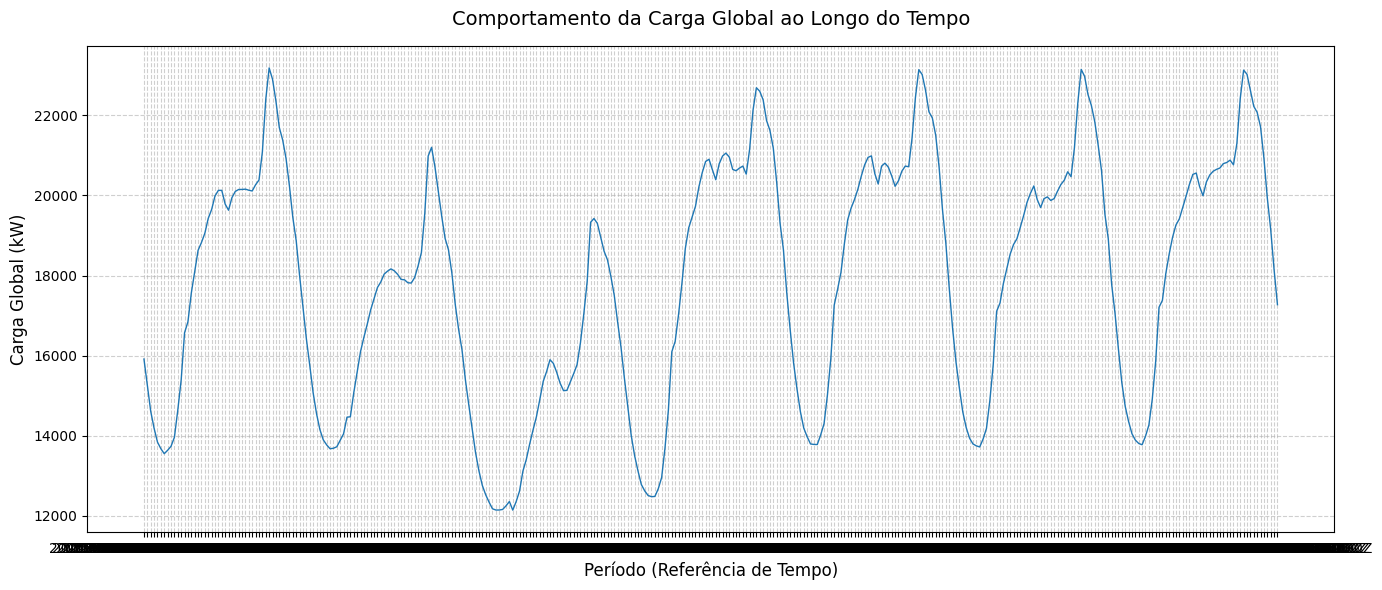

Interpretação 1: O gráfico em linha evidencia a evolução da carga global ao longo do período analisado, permitindo identificar visualmente os momentos exatos em que a demanda atinge seus picos máximos e ultrapassa a linha de 90% estipulada no Desafio 4.


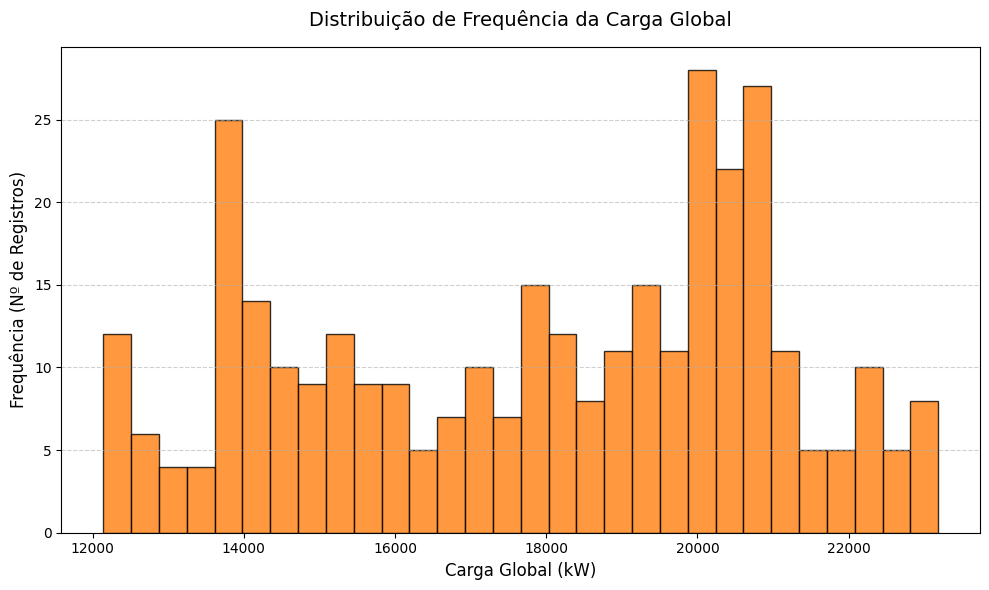

Interpretação 2: O histograma revela a concentração dos dados. É possível visualizar se o sistema operou na maior parte do tempo próximo à carga média, e como os eventos de alta demanda se comportam como exceções (cauda do gráfico) em relação ao volume total de registros.


In [41]:
# Desenvolva aqui o DESAFIO 6
import matplotlib.pyplot as plt

# Gráfico 1: Comportamento da carga ao longo do tempo
plt.figure(figsize=(14, 6))
plt.plot(dados['referencia_tempo'], dados['carga_global'], color='#1f77b4', linewidth=1)
plt.title('Comportamento da Carga Global ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Período (Referência de Tempo)', fontsize=12)
plt.ylabel('Carga Global (kW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Interpretação 1: O gráfico em linha evidencia a evolução da carga global ao longo do período analisado, permitindo identificar visualmente os momentos exatos em que a demanda atinge seus picos máximos e ultrapassa a linha de 90% estipulada no Desafio 4.")

# Gráfico 2: Distribuição da carga (Histograma)
plt.figure(figsize=(10, 6))
plt.hist(dados['carga_global'], bins=30, color='#ff7f0e', edgecolor='black', alpha=0.8)
plt.title('Distribuição de Frequência da Carga Global', fontsize=14, pad=15)
plt.xlabel('Carga Global (kW)', fontsize=12)
plt.ylabel('Frequência (Nº de Registros)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Interpretação 2: O histograma revela a concentração dos dados. É possível visualizar se o sistema operou na maior parte do tempo próximo à carga média, e como os eventos de alta demanda se comportam como exceções (cauda do gráfico) em relação ao volume total de registros.")

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [42]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

dados['referencia_tempo'] = pd.to_datetime(dados['referencia_tempo'])
data_min = dados['referencia_tempo'].min().strftime('%d/%m/%Y %H:%M')
data_max = dados['referencia_tempo'].max().strftime('%d/%m/%Y %H:%M')

regiao = "SP"
periodo = f"{data_min} a {data_max}"
qtd_registros = dados.shape[0]

carga_min = dados['carga_global'].min()
carga_max = dados['carga_global'].max()
carga_media = dados['carga_global'].mean()
mediana = dados['carga_global'].median()

limiar_alta_demanda = carga_max * 0.9
qtd_alta_demanda = dados[dados['carga_global'] >= limiar_alta_demanda].shape[0]
percentual_alta = (qtd_alta_demanda / qtd_registros) * 100

pico_bruto = dados.loc[dados['carga_global'].idxmax(), 'referencia_tempo']
momento_pico = pico_bruto.strftime('%d/%m/%Y %H:%M')

qtd_acima_media = dados[dados['carga_global'] > carga_media].shape[0]
perc_acima_media = (qtd_acima_media / qtd_registros) * 100
segundo_criterio = f"Carga acima da média com {qtd_acima_media} registros ({perc_acima_media:.1f}%)"

resumo_resultados = f'''
Região analisada: {regiao}
Período analisado: {periodo}
Quantidade de registros: {qtd_registros}
Carga mínima: {carga_min:.2f} kW
Carga máxima: {carga_max:.2f} kW
Carga média: {carga_media:.2f} kW
Mediana: {mediana:.2f} kW
Limiar de alta demanda: {limiar_alta_demanda:.2f} kW
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {percentual_alta:.2f}%
Momento do pico: {momento_pico}
Segundo critério: {segundo_criterio}
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 01/08/2025 03:30 a 08/08/2025 03:00
Quantidade de registros: 336
Carga mínima: 12139.25 kW
Carga máxima: 23185.31 kW
Carga média: 17870.83 kW
Mediana: 18199.13 kW
Limiar de alta demanda: 20866.78 kW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 01/08/2025 22:00
Segundo critério: Carga acima da média com 184 registros (54.8%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [39]:
!pip -q install -U google-genai

In [40]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [43]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**